# Compute the nucleosome shift of the +1, and if possible, +2, and +3

May 8, 2024

Goal: Create a procedure to compute the shift of the +1 nucleosome.

1. First look at some examples of nucleosome positioning for various phases of the cell cycle. By eye is there a shift that is computable.
2. Design a procedure to compute the +1 nucleosome based on neighbor bins of nucleosome fragment length.
3. Compute the shift from the baseline +1 position for all genes.


In [10]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)

In [18]:
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.200
1001/5574 - 00:00:07.096
2001/5574 - 00:00:13.141
3001/5574 - 00:00:18.967
4001/5574 - 00:00:24.719
5001/5574 - 00:00:30.548


In [19]:
promoter_analysis.correct_f_images_by_strand()

In [403]:
from src.nuc_p1_shift_analysis import ComputePlusOneShiftAnalysis

plus_one_analysis = ComputePlusOneShiftAnalysis(promoter_analysis)

In [404]:
plus_one_analysis.compute_p1_shift()

In [408]:
plus_one_analysis.normalize_plus_ones()

In [415]:
plus_one_analysis.join_with_replication_timing()

In [417]:
plus_one_analysis.save_plus_ones('output/deconvolved_plus_one_tracking')

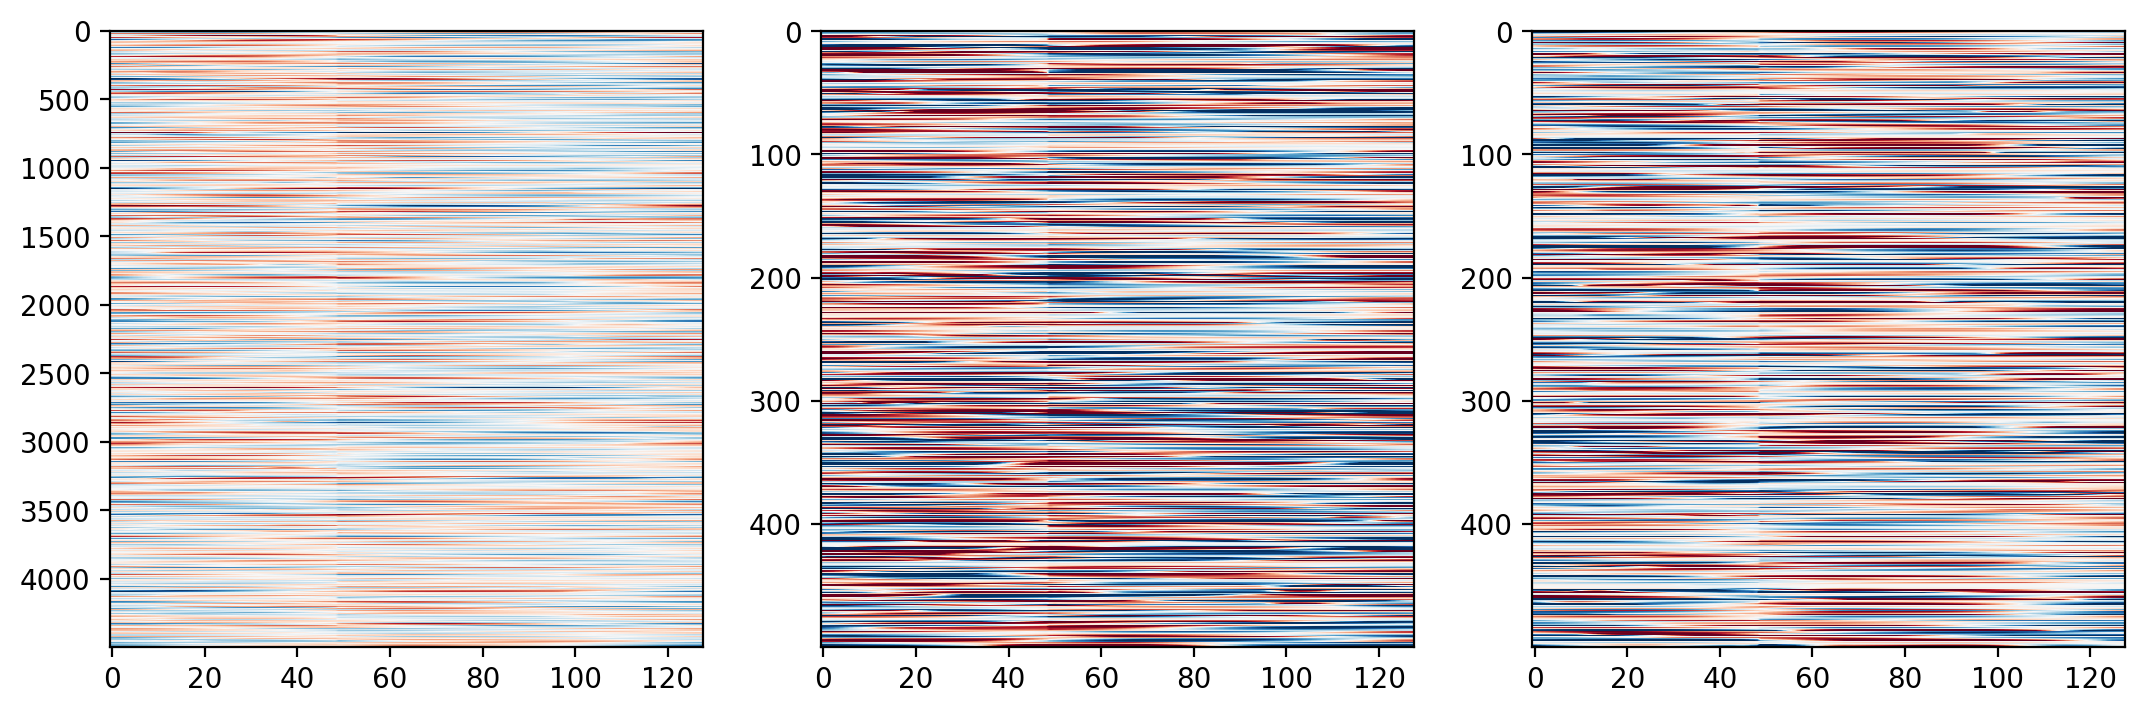

In [418]:
plt_genes = plus_one_analysis.repl_w_nuc_max.sort_values('replication_timing')
p1_genes_w_nuc_cov = plt_genes[plt_genes.bin_max > 10]
p1_orfs_to_plot = p1_genes_w_nuc_cov.index

plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
plt.imshow(p1_mean_only_norm.loc[p1_orfs_to_plot], aspect='auto', cmap='RdBu_r', 
           vmin=-2, vmax=2)

plt.subplot(1, 3, 2)
plt.imshow(p1_mean_only_norm.loc[p1_orfs_to_plot].head(500), aspect='auto', cmap='RdBu_r', 
           vmin=-2, vmax=2)

plt.subplot(1, 3, 3)
plt.imshow(p1_mean_only_norm.loc[p1_orfs_to_plot].tail(500), aspect='auto', cmap='RdBu_r', 
           vmin=-2, vmax=2)